# Assignment A3: OCR Comparison on img_2.jpg, img_3.jpg

Complete the tasks below in order. Use img_2.jpg and img_3.jpg and there matching ICDAR ground truth file.

In [52]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pytesseract
import easyocr
import re
import unicodedata
from paddleocr import PaddleOCR

# Set this if Tesseract is not in PATH
pytesseract.pytesseract.tesseract_cmd = r"C:\\Program Files\\Tesseract-OCR\\tesseract.exe"

## Question 1.1: Set Paths for images

**Syntax:** `Path(r"...")`


In [44]:
img_path = Path(r"C:\Projects\OCR\icdar2013\Challenge2_Test_Task12_Images\img_1.jpg")

## Question 1.2: Read and Display Image

**Syntax:** `cv2.imread(path)` and `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`

In [45]:
img_bgr = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

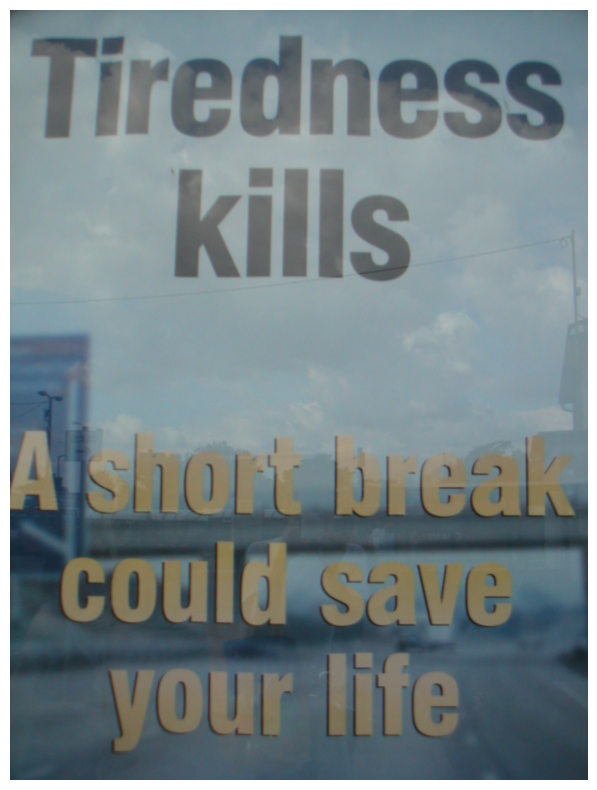

In [46]:
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

## Question 1.3: Read Ground Truth and Build gt_text <br> (Hint: modified the code to get gt_text for both img_2 and img_3)

**Syntax:** `Path.read_text(encoding, errors)` and `re.search(pattern, line)`

Keep the gt_words to gt_text conversion exactly as shown in the code cell below.

In [47]:
gt_path = Path(r"C:\Projects\OCR\icdar2013\Challenge2_Test_Task1_GT (1)\gt_img_1.txt")

In [48]:
raw_gt_text = gt_path.read_text(encoding="utf-8", errors="ignore")
gt_words = []
for line in raw_gt_text.splitlines():
    # ICDAR format example: x1, y1, x2, y2, "word"
    match = re.search(r'"(.*?)"\s*$', line)
    if match:
        gt_words.append(match.group(1))

# Fallback to raw text if parsing finds no quoted transcription tokens.
gt_text = " ".join(gt_words).strip() if gt_words else raw_gt_text.strip()
print("Parsed GT (img_2):", gt_text)
gt_text

Parsed GT (img_2): Tiredness kills A short break could save your life


'Tiredness kills A short break could save your life'

## Question 2: Define CER and WER Functions (Given)

**Syntax:** `levenshtein_distance(seq1, seq2)` and `compute_cer_wer(gt_text, pred_text, ...)`

Keep the function syntax consistent with the OCR tutorial notebook.

In [49]:
def normalize_ocr_text(text, lowercase=True, remove_punctuation=False):
    """Normalize OCR output text for fair CER/WER comparison across engines."""
    if text is None:
        text = ""
    if not isinstance(text, str):
        text = str(text)

    text = unicodedata.normalize("NFKC", text)
    text = text.replace("\r\n", "\n").replace("\r", "\n").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()

    if lowercase:
        text = text.lower()

    if remove_punctuation:
        text = re.sub(r"[^\w\s]", "", text)
        text = re.sub(r"\s+", " ", text).strip()

    return text


def levenshtein_distance(seq1, seq2):
    n, m = len(seq1), len(seq2)
    if n == 0:
        return m
    if m == 0:
        return n

    dp = [[0] * (m + 1) for _ in range(n + 1)]
    for i in range(n + 1):
        dp[i][0] = i
    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if seq1[i - 1] == seq2[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + cost
            )

    return dp[n][m]


def compute_cer_wer(
    gt_text,
    pred_text,
    lowercase=True,
    remove_punctuation=False,
    return_normalized_text=False,
    token_level="word",
):
    gt_norm = normalize_ocr_text(
        gt_text,
        lowercase=lowercase,
        remove_punctuation=remove_punctuation,
    )
    pred_norm = normalize_ocr_text(
        pred_text,
        lowercase=lowercase,
        remove_punctuation=remove_punctuation,
    )

    char_dist = levenshtein_distance(list(gt_norm), list(pred_norm))
    # Use max(ref_len, pred_len) denominator to keep CER in [0, 1].
    cer_den = max(1, len(gt_norm), len(pred_norm))
    cer = char_dist / cer_den

    if token_level == "char":
        gt_tokens = list(gt_norm)
        pred_tokens = list(pred_norm)
    else:
        gt_tokens = gt_norm.split()
        pred_tokens = pred_norm.split()

    token_dist = levenshtein_distance(gt_tokens, pred_tokens)
    # Use max(ref_tokens, pred_tokens) denominator to keep WER in [0, 1].
    wer_den = max(1, len(gt_tokens), len(pred_tokens))
    wer = token_dist / wer_den

    metrics = {
        "cer": cer,
        "wer": wer,
        "char_distance": char_dist,
        "token_distance": token_dist,
        "word_distance": token_dist,
        "gt_num_chars": len(gt_norm),
        "pred_num_chars": len(pred_norm),
        "gt_num_tokens": len(gt_tokens),
        "pred_num_tokens": len(pred_tokens),
        "gt_num_words": len(gt_tokens),
        "pred_num_words": len(pred_tokens),
        "cer_denominator": cer_den,
        "wer_denominator": wer_den,
        "normalization": {
            "lowercase": lowercase,
            "remove_punctuation": remove_punctuation,
            "token_level": token_level,
        },
    }

    if return_normalized_text:
        metrics["gt_normalized"] = gt_norm
        metrics["pred_normalized"] = pred_norm

    return metrics


def show_metrics(name, gt_text, pred_text, **kwargs):
    metrics = compute_cer_wer(gt_text, pred_text, **kwargs)
    print(f"{name} metrics:")
    print(f"  CER: {metrics['cer']:.4f} ({metrics['char_distance']} / {metrics['cer_denominator']})")
    print(f"  WER: {metrics['wer']:.4f} ({metrics['token_distance']} / {metrics['wer_denominator']})")
    print(f"  Normalization: {metrics['normalization']}")
    return metrics

## Question 3.1: Run PyTesseract OCR and calcaulte CER and WER

**Syntax:** `pytesseract.image_to_string(image, lang="eng")` <br>
**Syntax:** `show_metrics("Notes", gt_text, detected_text)`

In [50]:
img_pyt = pytesseract.image_to_string(img_rgb, lang='eng')
show_metrics("Tesseract", gt_text, img_pyt)


Tesseract metrics:
  CER: 0.8000 (40 / 50)
  WER: 1.0000 (9 / 9)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


{'cer': 0.8,
 'wer': 1.0,
 'char_distance': 40,
 'token_distance': 9,
 'word_distance': 9,
 'gt_num_chars': 50,
 'pred_num_chars': 19,
 'gt_num_tokens': 9,
 'pred_num_tokens': 8,
 'gt_num_words': 9,
 'pred_num_words': 8,
 'cer_denominator': 50,
 'wer_denominator': 9,
 'normalization': {'lowercase': True,
  'remove_punctuation': False,
  'token_level': 'word'}}

## Question 3.2: Run EasyOCR and calcaulte CER and WER

**Syntax:** `easyocr.Reader(["en"], gpu=False).readtext(image_path, detail=1, paragraph=False)`

In [57]:
img_easy = easyocr.Reader(['en'], gpu=False).readtext(img_rgb, detail=1, paragraph=False)

show_metrics("EasyOCR", gt_text, img_easy)

Using CPU. Note: This module is much faster with a GPU.
c:\Projects\OCR\Handheld-OCR-Translator\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


EasyOCR metrics:
  CER: 0.9536 (822 / 862)
  WER: 1.0000 (53 / 53)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


{'cer': 0.9535962877030162,
 'wer': 1.0,
 'char_distance': 822,
 'token_distance': 53,
 'word_distance': 53,
 'gt_num_chars': 50,
 'pred_num_chars': 862,
 'gt_num_tokens': 9,
 'pred_num_tokens': 53,
 'gt_num_words': 9,
 'pred_num_words': 53,
 'cer_denominator': 862,
 'wer_denominator': 53,
 'normalization': {'lowercase': True,
  'remove_punctuation': False,
  'token_level': 'word'}}

## Question 3.3: Run PaddleOCR and calculate CER and WER <br> (Hint: use the given code)

**Syntax:** `PaddleOCR(...).predict(image_path)` and `page.get("rec_texts", [])`

In [ ]:
paddle_reader = PaddleOCR(
    use_textline_orientation=True,
    lang="en",
    device="cpu",
    enable_mkldnn=False,
    enable_hpi=False,
    engine="paddle",
)

img_pad = paddle_reader.predict(str(img_path))


Creating model: ('PP-LCNet_x1_0_doc_ori', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\evanz\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\evanz\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\evanz\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\evanz\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, 'paddle')
Model files already exist. Using cached files. To redownload, please delete th

PaddleOCR metrics:
  CER: 0.9786 (2246 / 2295)
  WER: 1.0000 (261 / 261)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


{'cer': 0.9786492374727669,
 'wer': 1.0,
 'char_distance': 2246,
 'token_distance': 261,
 'word_distance': 261,
 'gt_num_chars': 50,
 'pred_num_chars': 2295,
 'gt_num_tokens': 9,
 'pred_num_tokens': 261,
 'gt_num_words': 9,
 'pred_num_words': 261,
 'cer_denominator': 2295,
 'wer_denominator': 261,
 'normalization': {'lowercase': True,
  'remove_punctuation': False,
  'token_level': 'word'}}

In [64]:
texts_2 = []
for page in img_pad:
    texts_2.extend(page.get("rec_texts", []))

paddle_text_2 = " ".join(texts_2).strip()
show_metrics("PaddleOCR", gt_text, paddle_text_2)

PaddleOCR metrics:
  CER: 0.0400 (2 / 50)
  WER: 0.1111 (1 / 9)
  Normalization: {'lowercase': True, 'remove_punctuation': False, 'token_level': 'word'}


{'cer': 0.04,
 'wer': 0.1111111111111111,
 'char_distance': 2,
 'token_distance': 1,
 'word_distance': 1,
 'gt_num_chars': 50,
 'pred_num_chars': 48,
 'gt_num_tokens': 9,
 'pred_num_tokens': 8,
 'gt_num_words': 9,
 'pred_num_words': 8,
 'cer_denominator': 50,
 'wer_denominator': 9,
 'normalization': {'lowercase': True,
  'remove_punctuation': False,
  'token_level': 'word'}}

## Question 4: Save Outputs (All Methods)

**Syntax:** `Path.mkdir(exist_ok=True)` and `Path.write_text(content, encoding="utf-8")`